# **Notebook: Double Descent**

Nombre:

Numero de estudiante:

---

Esta notebook investiga el fenómeno **double descent** que ocurre en las Redes Neuronales.

En el aprendizaje automático, a menudo esperamos que a medida que la capacidad de un modelo (por ejemplo, el número de parámetros) aumenta, el error de entrenamiento disminuya y el error de prueba eventualmente aumente después de cierto punto (el clásico "overfitting"). Sin embargo, el fenómeno de Double Descent desafía esta intuición al mostrar que, en ciertos escenarios, a medida que la capacidad del modelo continúa aumentando más allá del punto de overfitting, el error de prueba puede volver a disminuir.

En esta notebook:

- Utilizamos el dataset MNIST-1D que se puede encontrar en https://github.com/greydanus/mnist1d.
- Entrenamos redes con diferentes capacidades (variando el número de unidades ocultas)
- Analizamos cómo el ruido en las etiquetas del conjunto de entrenamiento influye en la forma de la curva Double Descent.

## Dataset

In [9]:
# Instalar el dataset MNIST 1D
#!pip install git+https://github.com/greydanus/mnist1d

In [2]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
import mnist1d
import random
random.seed(0)

DEVICE = str(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print('Using:', DEVICE)

Using: cpu


In [3]:
def get_noisy_mnist1d_dataset(noise_rate=0.0):
    """
    Generates the MNIST-1D dataset with a specified amount of noise in the training labels.

    Args:
        noise_rate (float): The proportion of training labels to flip randomly.

    Returns:
        dict: A dictionary containing the noisy dataset.
    """
    args = mnist1d.data.get_dataset_args()
    args.num_samples = 8000
    args.train_split = 0.5
    args.corr_noise_scale = 0.25
    args.iid_noise_scale = 2e-2
    data = mnist1d.data.get_dataset(args, path='./mnist1d_data.pkl',
                                    download=False, regenerate=True)

    # Add noise to training labels
    for c_y in range(len(data['y'])):
        random_number = random.random()
        if random_number < noise_rate:
            random_int = int(random.random() * 10)
            data['y'][c_y] = random_int

    return data

In [4]:
data = get_noisy_mnist1d_dataset(noise_rate=0.0)

# The training and test input and outputs are in
# data['x'], data['y'], data['x_test'], and data['y_test']
print("Examples in training set: {}".format(len(data['y'])))
print("Examples in test set: {}".format(len(data['y_test'])))
print("Dimensionality of each example: {}".format(data['x'].shape[-1]))

Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Examples in training set: 4000
Examples in test set: 4000
Dimensionality of each example: 40


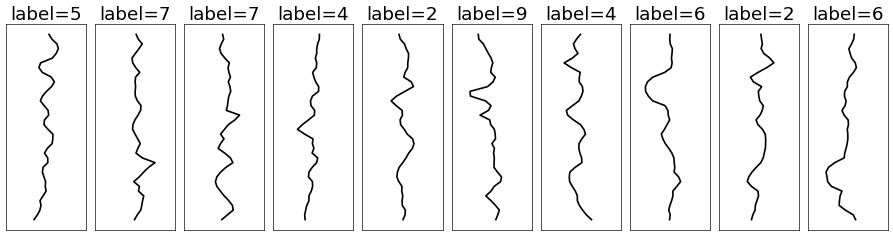

In [5]:
def plot_signals(xs, t, labels=None, ratio=2.6, zoom=1):
    rows, cols = 1, 10
    fig = plt.figure(figsize=[cols*1.5,rows*1.5*ratio], dpi=60)
    for r in range(rows):
        for c in range(cols):
            ix = r*cols + c
            x, t = xs[ix], t
            ax = plt.subplot(rows,cols,ix+1)

            # plot the data
            plt.plot(x, t, 'k-', linewidth=2)
            if labels is not None:
                plt.title("label=" + str(labels[ix]), fontsize=22)

            plt.xlim(-zoom,zoom) ; plt.ylim(-zoom,zoom)
            plt.gca().invert_yaxis() ; plt.xticks([], []), plt.yticks([], [])
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.tight_layout() ; plt.show()
    return fig


# Sample 10 random examples from test
num_test_examples = len(data['y_test'])
sample_indices_test = random.sample(range(num_test_examples), 10)

xs = data['x_test'][sample_indices_test]
labels = data['y_test'][sample_indices_test]
t = data['t']
_ = plot_signals(xs, t, labels=labels, ratio=2.7, zoom=6)

Ahora definiremos la función `get_model`, encargada de construir nuestra red neuronal.

**Tarea:**
Completa la función `get_model` con las siguientes especificaciones:

1. Define las dimensiones:
    * Entrada (D_i): debe coincidir con la dimensionalidad de cada muestra del dataset MNIST-1D.
    * Oculta (n_hidden): se recibe como argumento de la función.
    * Salida (D_o): igual al número de clases.

2. Crea una arquitectura secuencial con las siguientes capas:
    - Capa lineal de entrada.
    - Activación ReLU.
    - Capa lineal oculta.
    - Activación ReLU.
    - Capa lineal de salida.

3. Devuelve el modelo resultante.

In [13]:
def get_model(n_hidden):

  D_i = data['x'].shape[-1]    # Input dimensions
  D_k = n_hidden   # Hidden dimensions
  D_o = len(np.unique(data['y']))    # Output dimensions

  model = nn.Sequential(
    nn.Linear(D_i, D_k),    # Input to hidden layer
    nn.ReLU(),              # First activation
    nn.Linear(D_k, D_k),    # Hidden to hidden layer
    nn.ReLU(),              # Second activation
    nn.Linear(D_k, D_o)     # Hidden to output layer
  )

  # Move model to appropriate device (CPU/GPU)
  model = model.to(DEVICE)

  # Return the model
  return model

## Entrenamiento y visualización de la curva *Double Descent*

En esta sección vamos a explorar cómo varían el **error de entrenamiento** y el **error de prueba** al aumentar la capacidad de una red neuronal.

**Tu tarea:**

1. Entrena redes neuronales con distintos números de unidades ocultas (`n_hidden`) durante **1000 épocas**, usando los siguientes tamaños de capa oculta:  
   `[2, 10, 26, 45, 48, 50, 55, 70, 120, 200, 250]`.  
2. Registra los errores finales de entrenamiento y prueba para cada modelo.  
3. Grafica los errores en función del número de unidades ocultas para visualizar la **curva de Double Descent**.  
4. Añade una línea vertical que marque el **interpolation threshold**, que se puede representar como el punto en que el número de parámetros del modelo se aproxima al número de ejemplos de entrenamiento. El pico del error de prueba suele aparecer cerca de esta región.

> 💡 **Nota:** la ejecución del código puede tomar un tiempo considerable, ¡así que quizás sea un buen momento para tomar un descanso!


### DATA PREPARATION


In [15]:
# =====================================================
# DATA PREPARATION
# =====================================================

X_train = torch.FloatTensor(data['x'])
y_train = torch.LongTensor(data['y'])
X_test = torch.FloatTensor(data['x_test'])
y_test = torch.LongTensor(data['y_test'])

# TensorDataset objects
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# DataLoader instances
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Training samples: 4000
Test samples: 4000
Batch size: 64
Number of training batches: 63
Number of test batches: 63


### FUNCIONES TRAINING Y EVALUATION

In [14]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    
    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        criterion: Loss function
        optimizer: Optimizer
        device: Device to run on (CPU/GPU)
    
    Returns:
        float: Average training loss for the epoch
    """
    model.train()
    total_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # Move data to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def evaluate(model, test_loader, criterion, device):
    """
    Evaluate the model on test data.
    
    Args:
        model: Neural network model
        test_loader: DataLoader for test data
        criterion: Loss function
        device: Device to run on (CPU/GPU)
    
    Returns:
        float: Average test loss
    """
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            # Move data to device
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item()
    
    return total_loss / len(test_loader)

### TRAINING LOOP

In [17]:
hidden_sizes = [2, 10, 26, 45, 48, 50, 55, 70, 120, 200, 250]

# Resultados
train_losses_final = []  # Final training loss for each model
test_losses_final = []   # Final test loss for each model
train_histories = []     # Full training history for each model
test_histories = []      # Full test history for each model

print("\n" + "="*60)
print("STARTING DOUBLE DESCENT EXPERIMENT")
print("="*60)
print(f"Training {len(hidden_sizes)} models with 1000 epochs each")
print(f"Hidden sizes: {hidden_sizes}")
print("="*60 + "\n")

# Train models with different capacities
for idx, n_hidden in enumerate(hidden_sizes):
    print(f"\n{'='*60}")
    print(f"MODEL {idx+1}/{len(hidden_sizes)}: n_hidden = {n_hidden}")
    print(f"{'='*60}")
    
    model = get_model(n_hidden)
    
    # Initialize optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    # Storage for this model's history
    train_loss_history = []
    test_loss_history = []
    
    # Training loop
    num_epochs = 100
    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        train_loss_history.append(train_loss)
        
        # Evaluate on test set
        test_loss = evaluate(model, test_loader, criterion, DEVICE)
        test_loss_history.append(test_loss)
        
        # Print progress
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
    
    # Store results
    train_losses_final.append(train_loss_history[-1])
    test_losses_final.append(test_loss_history[-1])
    train_histories.append(train_loss_history)
    test_histories.append(test_loss_history)
    
    print(f"  ✓ Completed! Final - Train: {train_loss_history[-1]:.4f}, Test: {test_loss_history[-1]:.4f}")

print("\n" + "="*60)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60 + "\n")


STARTING DOUBLE DESCENT EXPERIMENT
Training 11 models with 1000 epochs each
Hidden sizes: [2, 10, 26, 45, 48, 50, 55, 70, 120, 200, 250]


MODEL 1/11: n_hidden = 2
  Epoch [100/100] - Train Loss: 1.7479, Test Loss: 1.7605
  ✓ Completed! Final - Train: 1.7479, Test: 1.7605

MODEL 2/11: n_hidden = 10
  Epoch [100/100] - Train Loss: 1.2372, Test Loss: 1.3293
  ✓ Completed! Final - Train: 1.2372, Test: 1.3293

MODEL 3/11: n_hidden = 26
  Epoch [100/100] - Train Loss: 0.8639, Test Loss: 1.1625
  ✓ Completed! Final - Train: 0.8639, Test: 1.1625

MODEL 4/11: n_hidden = 45
  Epoch [100/100] - Train Loss: 0.5720, Test Loss: 1.2062
  ✓ Completed! Final - Train: 0.5720, Test: 1.2062

MODEL 5/11: n_hidden = 48
  Epoch [100/100] - Train Loss: 0.5427, Test Loss: 1.2544
  ✓ Completed! Final - Train: 0.5427, Test: 1.2544

MODEL 6/11: n_hidden = 50
  Epoch [100/100] - Train Loss: 0.5418, Test Loss: 1.2855
  ✓ Completed! Final - Train: 0.5418, Test: 1.2855

MODEL 7/11: n_hidden = 55
  Epoch [100/100] -

### VISUALIZACIONES

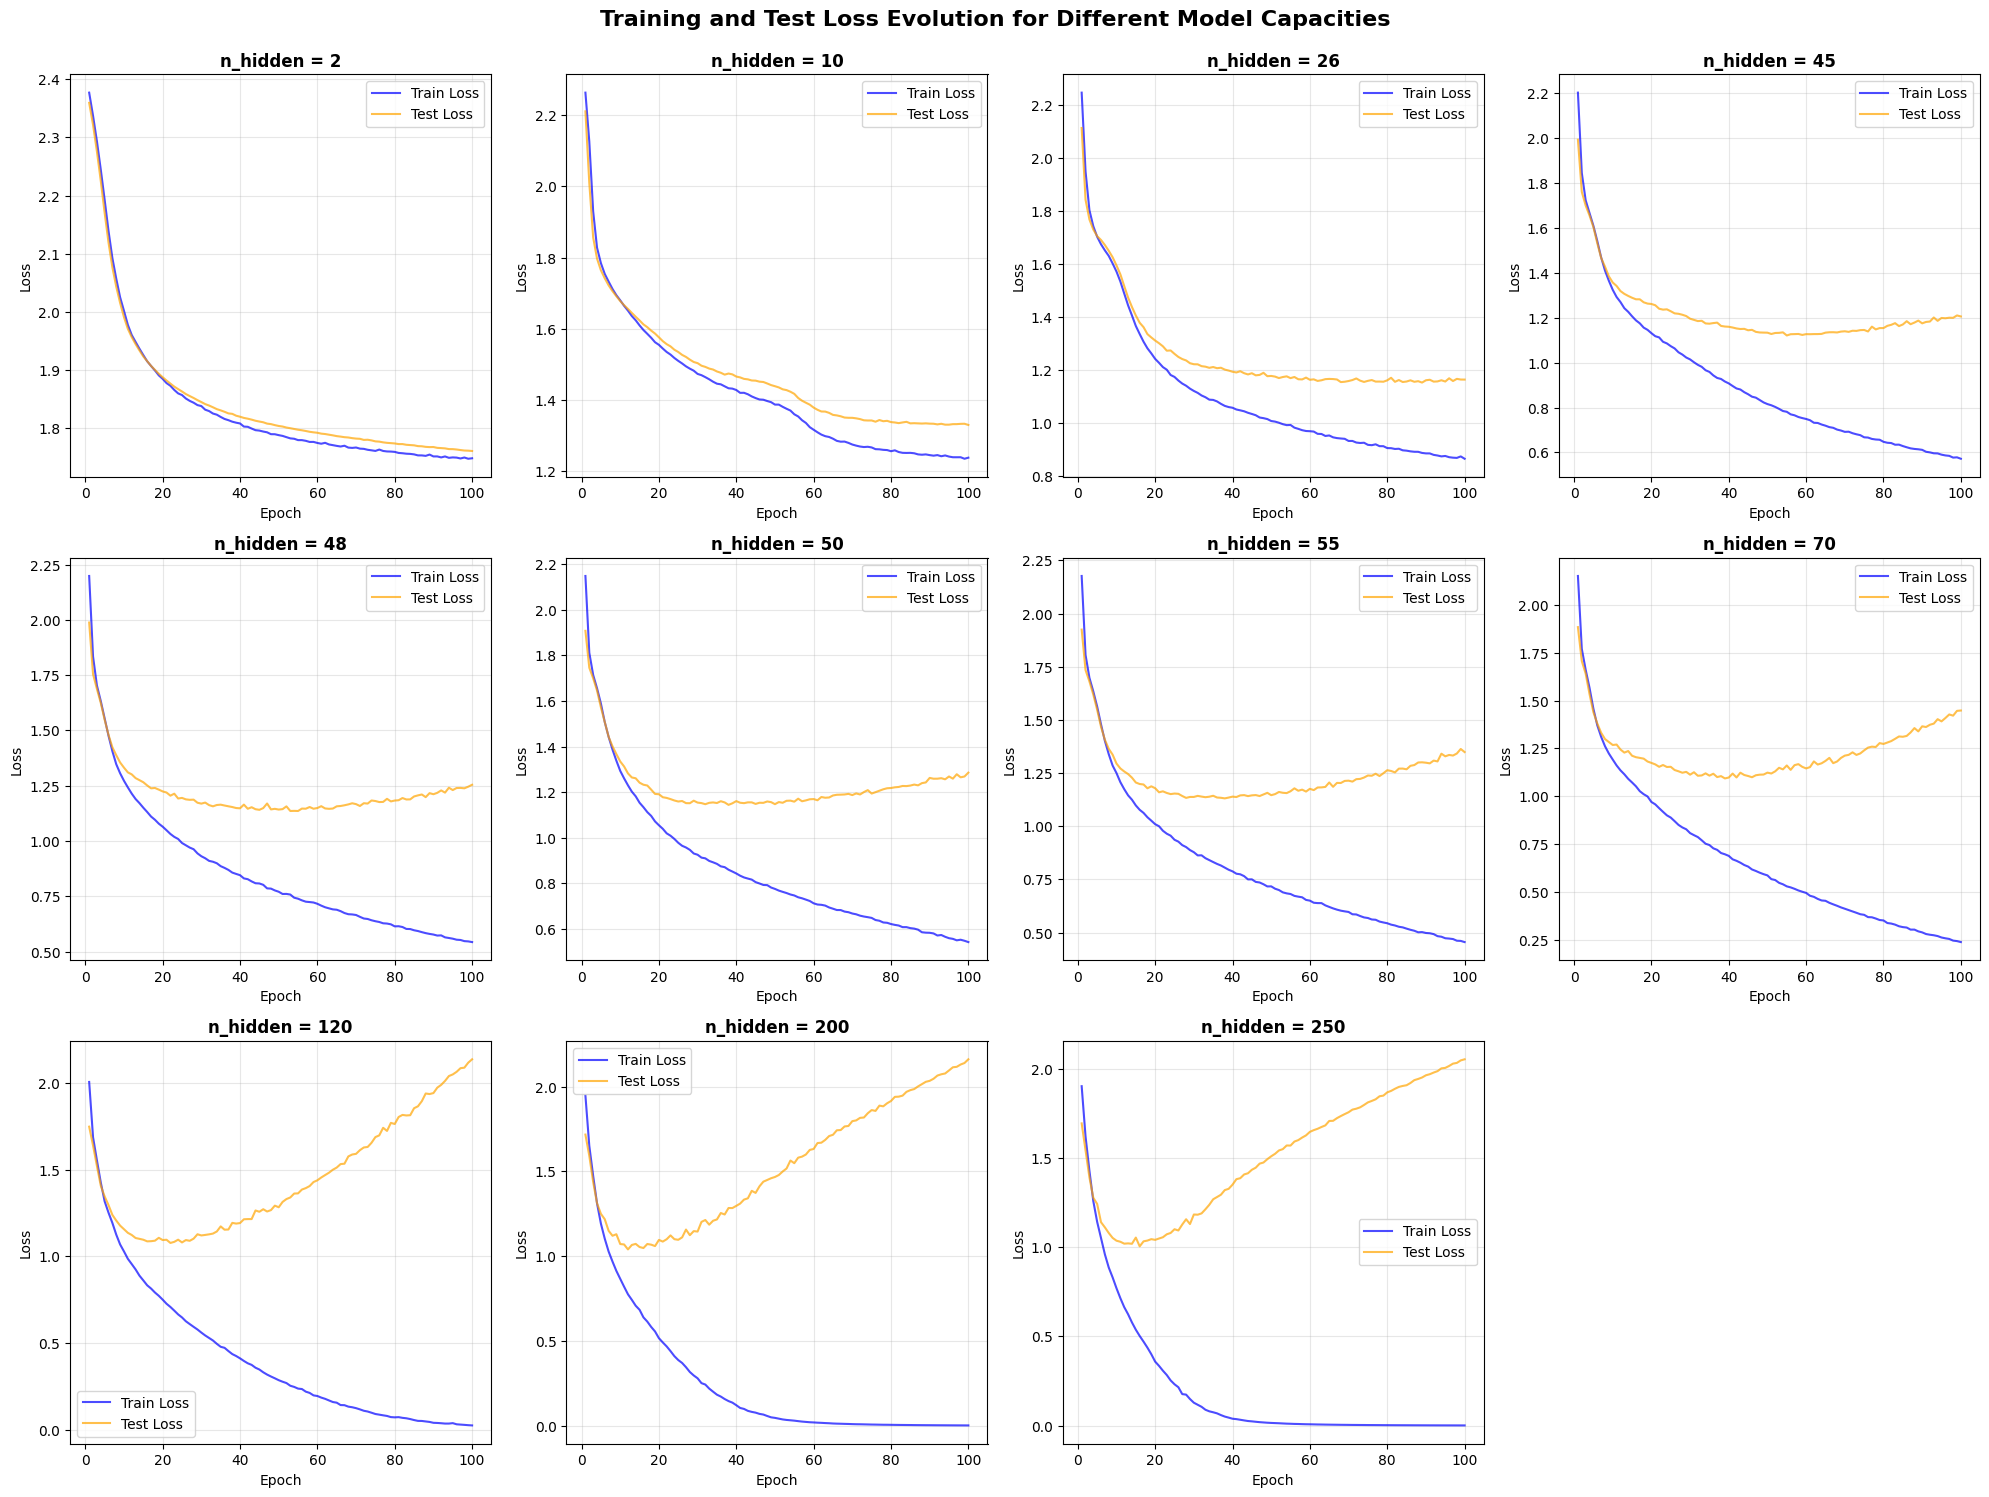

In [20]:

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, n_hidden in enumerate(hidden_sizes):
    ax = axes[idx]
    epochs = range(1, len(train_histories[idx]) + 1)
    
    # Plot training and test loss
    ax.plot(epochs, train_histories[idx], 'b-', label='Train Loss', alpha=0.7)
    ax.plot(epochs, test_histories[idx], 'orange', label='Test Loss', alpha=0.7)
    
    # Formatting
    ax.set_title(f'n_hidden = {n_hidden}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the extra subplot
axes[-1].axis('off')

plt.suptitle('Training and Test Loss Evolution for Different Model Capacities', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Explorando el *Double Descent* con etiquetas ruidosas

En esta sección repetiremos el experimento anterior, pero introduciendo **ruido en las etiquetas** del conjunto de entrenamiento para analizar cómo afecta al fenómeno *Double Descent*.

Entrenaremos nuevamente el modelo con los mismos tamaños de capa oculta:  
`[2, 10, 26, 45, 48, 50, 55, 70, 120, 200, 250]`,  
pero esta vez usaremos datasets en los que un porcentaje de las etiquetas ha sido aleatorizado. Realizaremos el experimento con dos niveles de ruido: **10 %** y **30 %**.

Después de entrenar los modelos para cada nivel de ruido, graficaremos las curvas de error de entrenamiento y prueba, similar a como lo hicimos anteriormente.

**Tu tarea:**

1. Ejecuta la celda siguiente para cargar los datasets con **10 %** y **30 %** de ruido.  
2. Adapta el código de entrenamiento y visualización de la sección anterior para entrenar los modelos con los conjuntos ruidosos y graficar los resultados.


In [21]:
# Carga el dataset MNIST-1D con 10% de ruido en las etiquetas de entrenamiento
data_noisy_10 = get_noisy_mnist1d_dataset(noise_rate=0.10)

# Puedes imprimir información sobre el dataset ruidoso para verificarlo
print("Dataset con 10% de ruido:")
print("Ejemplos en entrenamiento:", len(data_noisy_10['y']))
print("Ejemplos en prueba:", len(data_noisy_10['y_test']))
print("-" * 20)

# Repite el proceso para el 30% de ruido (modificando la tasa de ruido)
data_noisy_30 = get_noisy_mnist1d_dataset(noise_rate=0.30)

print("Dataset con 30% de ruido:")
print("Ejemplos en entrenamiento:", len(data_noisy_30['y']))
print("Ejemplos en prueba:", len(data_noisy_30['y_test']))

Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Dataset con 10% de ruido:
Ejemplos en entrenamiento: 4000
Ejemplos en prueba: 4000
--------------------
Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Dataset con 30% de ruido:
Ejemplos en entrenamiento: 4000
Ejemplos en prueba: 4000


### 10% NOISE

In [22]:
# Prepare DataLoaders for 10% noise
X_train_10 = torch.FloatTensor(data_noisy_10['x'])
y_train_10 = torch.LongTensor(data_noisy_10['y'])
X_test_10 = torch.FloatTensor(data_noisy_10['x_test'])
y_test_10 = torch.LongTensor(data_noisy_10['y_test'])

train_dataset_10 = TensorDataset(X_train_10, y_train_10)
test_dataset_10 = TensorDataset(X_test_10, y_test_10)

train_loader_10 = DataLoader(train_dataset_10, batch_size=batch_size, shuffle=True)
test_loader_10 = DataLoader(test_dataset_10, batch_size=batch_size, shuffle=False)

# Storage for 10% noise results
train_losses_final_10 = []
test_losses_final_10 = []
train_histories_10 = []
test_histories_10 = []

# Train models with 10% noise
for idx, n_hidden in enumerate(hidden_sizes):
    print(f"\n{'='*60}")
    print(f"MODEL {idx+1}/{len(hidden_sizes)}: n_hidden = {n_hidden} (10% noise)")
    print(f"{'='*60}")
    
    # Create model
    model = get_model(n_hidden)
    
    # Initialize optimizer and loss
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    # Storage for this model's history
    train_loss_history = []
    test_loss_history = []
    
    # Training loop
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader_10, criterion, optimizer, DEVICE)
        train_loss_history.append(train_loss)
        
        test_loss = evaluate(model, test_loader_10, criterion, DEVICE)
        test_loss_history.append(test_loss)
        
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
    
    # Store results
    train_losses_final_10.append(train_loss_history[-1])
    test_losses_final_10.append(test_loss_history[-1])
    train_histories_10.append(train_loss_history)
    test_histories_10.append(test_loss_history)
    
    print(f"  ✓ Completed! Final - Train: {train_loss_history[-1]:.4f}, Test: {test_loss_history[-1]:.4f}")

print("\n✓ All models with 10% noise trained successfully!\n")


MODEL 1/11: n_hidden = 2 (10% noise)
  Epoch [100/100] - Train Loss: 1.8470, Test Loss: 1.7221
  ✓ Completed! Final - Train: 1.8470, Test: 1.7221

MODEL 2/11: n_hidden = 10 (10% noise)
  Epoch [100/100] - Train Loss: 1.5212, Test Loss: 1.4012
  ✓ Completed! Final - Train: 1.5212, Test: 1.4012

MODEL 3/11: n_hidden = 26 (10% noise)
  Epoch [100/100] - Train Loss: 1.2097, Test Loss: 1.2821
  ✓ Completed! Final - Train: 1.2097, Test: 1.2821

MODEL 4/11: n_hidden = 45 (10% noise)
  Epoch [100/100] - Train Loss: 0.8533, Test Loss: 1.2695
  ✓ Completed! Final - Train: 0.8533, Test: 1.2695

MODEL 5/11: n_hidden = 48 (10% noise)
  Epoch [100/100] - Train Loss: 0.8469, Test Loss: 1.3108
  ✓ Completed! Final - Train: 0.8469, Test: 1.3108

MODEL 6/11: n_hidden = 50 (10% noise)
  Epoch [100/100] - Train Loss: 0.7692, Test Loss: 1.2882
  ✓ Completed! Final - Train: 0.7692, Test: 1.2882

MODEL 7/11: n_hidden = 55 (10% noise)
  Epoch [100/100] - Train Loss: 0.7290, Test Loss: 1.2792
  ✓ Completed! F

### 30% NOISE

In [23]:
# Prepare DataLoaders for 30% noise
X_train_30 = torch.FloatTensor(data_noisy_30['x'])
y_train_30 = torch.LongTensor(data_noisy_30['y'])
X_test_30 = torch.FloatTensor(data_noisy_30['x_test'])
y_test_30 = torch.LongTensor(data_noisy_30['y_test'])

train_dataset_30 = TensorDataset(X_train_30, y_train_30)
test_dataset_30 = TensorDataset(X_test_30, y_test_30)

train_loader_30 = DataLoader(train_dataset_30, batch_size=batch_size, shuffle=True)
test_loader_30 = DataLoader(test_dataset_30, batch_size=batch_size, shuffle=False)

# Storage for 30% noise results
train_losses_final_30 = []
test_losses_final_30 = []
train_histories_30 = []
test_histories_30 = []

# Train models with 30% noise
for idx, n_hidden in enumerate(hidden_sizes):
    print(f"\n{'='*60}")
    print(f"MODEL {idx+1}/{len(hidden_sizes)}: n_hidden = {n_hidden} (30% noise)")
    print(f"{'='*60}")
    
    # Create model
    model = get_model(n_hidden)
    
    # Initialize optimizer and loss
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    # Storage for this model's history
    train_loss_history = []
    test_loss_history = []
    
    # Training loop
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader_30, criterion, optimizer, DEVICE)
        train_loss_history.append(train_loss)
        
        test_loss = evaluate(model, test_loader_30, criterion, DEVICE)
        test_loss_history.append(test_loss)
        
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
    
    # Store results
    train_losses_final_30.append(train_loss_history[-1])
    test_losses_final_30.append(test_loss_history[-1])
    train_histories_30.append(train_loss_history)
    test_histories_30.append(test_loss_history)
    


MODEL 1/11: n_hidden = 2 (30% noise)
  Epoch [100/100] - Train Loss: 2.0572, Test Loss: 1.8685

MODEL 2/11: n_hidden = 10 (30% noise)
  Epoch [100/100] - Train Loss: 1.8186, Test Loss: 1.5513

MODEL 3/11: n_hidden = 26 (30% noise)
  Epoch [100/100] - Train Loss: 1.5870, Test Loss: 1.4801

MODEL 4/11: n_hidden = 45 (30% noise)
  Epoch [100/100] - Train Loss: 1.2838, Test Loss: 1.4936

MODEL 5/11: n_hidden = 48 (30% noise)
  Epoch [100/100] - Train Loss: 1.2450, Test Loss: 1.5560

MODEL 6/11: n_hidden = 50 (30% noise)
  Epoch [100/100] - Train Loss: 1.2000, Test Loss: 1.5045

MODEL 7/11: n_hidden = 55 (30% noise)
  Epoch [100/100] - Train Loss: 1.0934, Test Loss: 1.5845

MODEL 8/11: n_hidden = 70 (30% noise)
  Epoch [100/100] - Train Loss: 0.8732, Test Loss: 1.7138

MODEL 9/11: n_hidden = 120 (30% noise)
  Epoch [100/100] - Train Loss: 0.1411, Test Loss: 2.6404

MODEL 10/11: n_hidden = 200 (30% noise)
  Epoch [100/100] - Train Loss: 0.0071, Test Loss: 2.9655

MODEL 11/11: n_hidden = 250

### VISUALIZATIONS

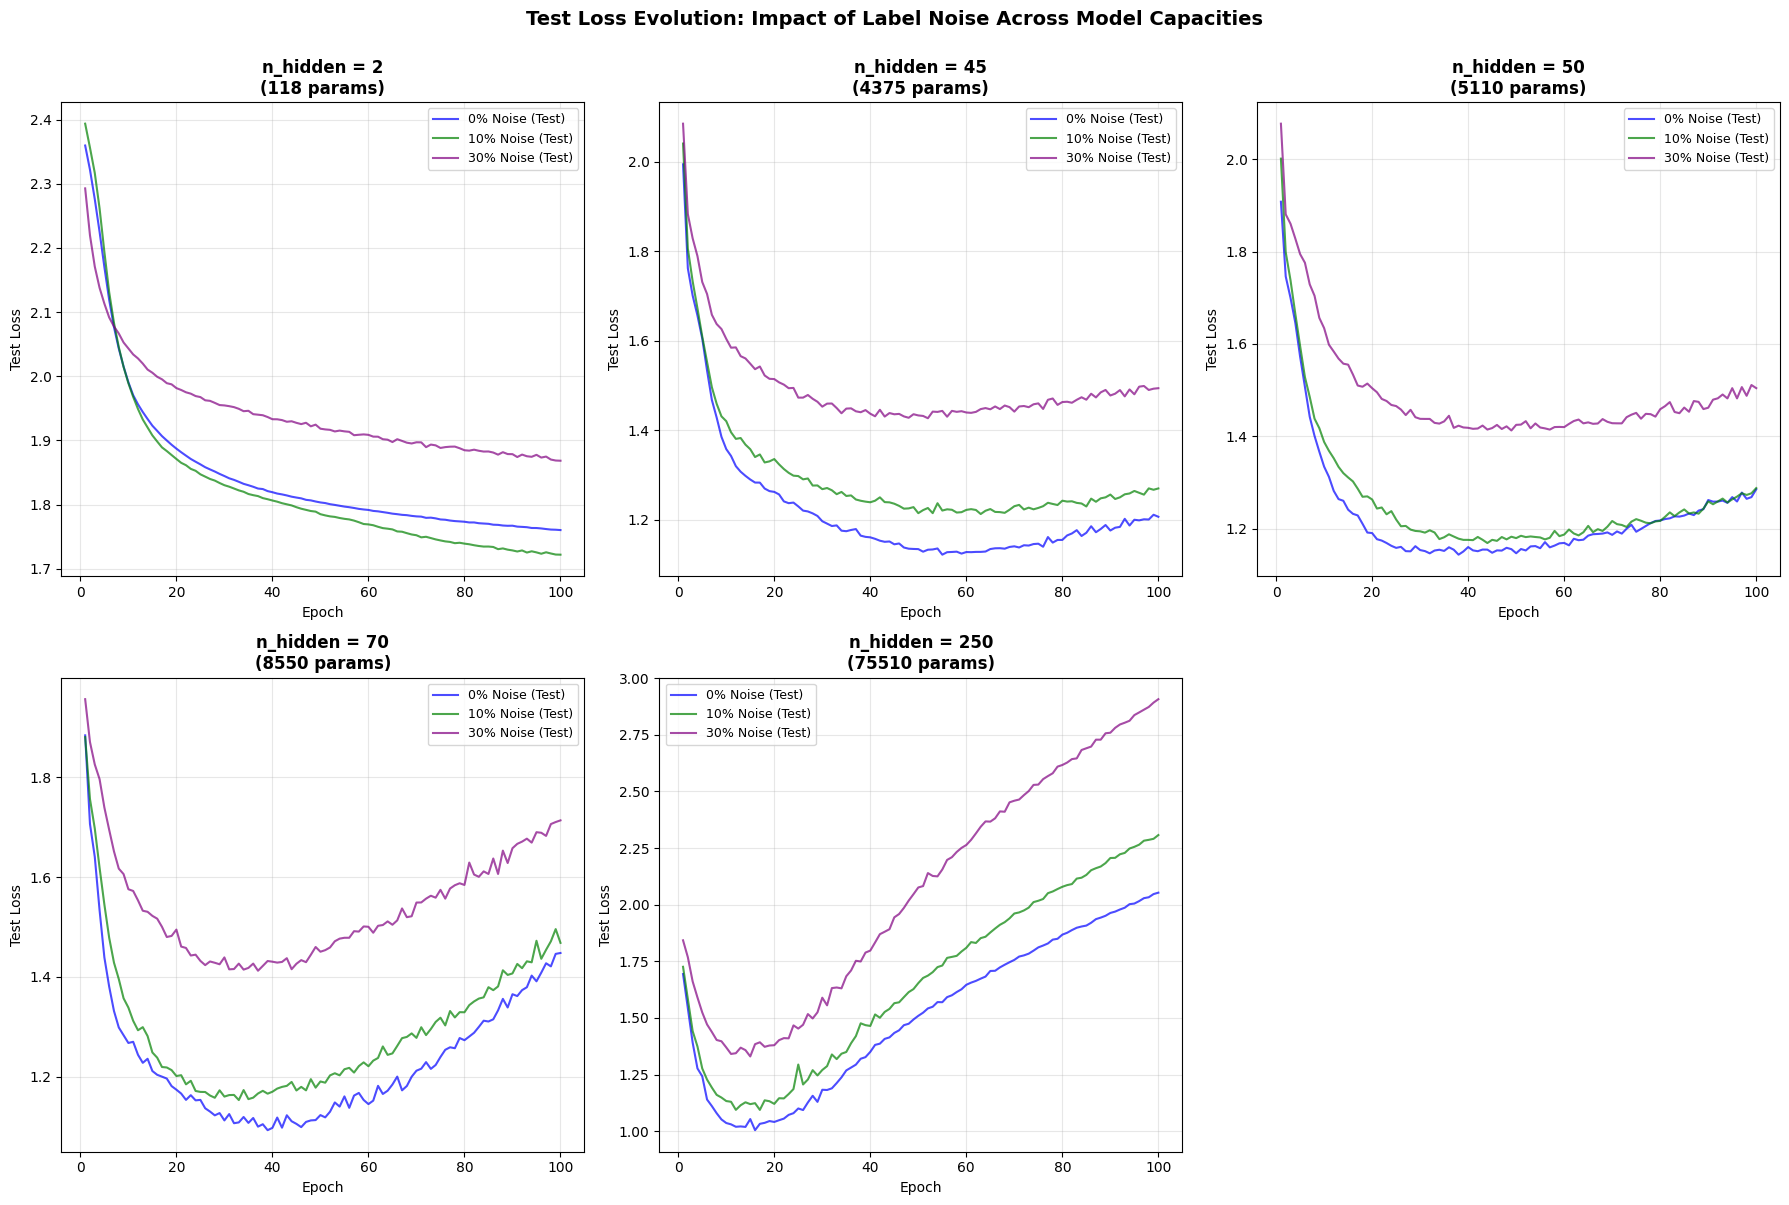

In [27]:
selected_indices = [0, 3, 5, 7, 10]  # n_hidden: 2, 45, 50, 70, 250
selected_sizes = [hidden_sizes[i] for i in selected_indices]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for plot_idx, model_idx in enumerate(selected_indices):
    ax = axes[plot_idx]
    n_hidden = hidden_sizes[model_idx]
    epochs = range(1, num_epochs + 1)
    
    # Plot test losses for all noise levels
    ax.plot(epochs, test_histories[model_idx], 'b-', 
            label='0% Noise (Test)', linewidth=1.5, alpha=0.7)
    ax.plot(epochs, test_histories_10[model_idx], 'g-', 
            label='10% Noise (Test)', linewidth=1.5, alpha=0.7)
    ax.plot(epochs, test_histories_30[model_idx], color='purple', 
            label='30% Noise (Test)', linewidth=1.5, alpha=0.7)
    
    ax.set_title(f'n_hidden = {n_hidden}\n({num_parameters[model_idx]} params)', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide the last subplot
axes[-1].axis('off')

plt.suptitle('Test Loss Evolution: Impact of Label Noise Across Model Capacities', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Preguntas finales

1. ¿Cómo afecta el **ruido en las etiquetas** al error mínimo de entrenamiento alcanzable? ¿Por qué ocurre esto?  
2. Según tus observaciones, ¿cómo influye el **ruido en las etiquetas** en el fenómeno de *Double Descent*, especialmente en relación con la **capacidad del modelo** y su **capacidad de generalización**?  
3. En *Deep Learning*, ¿es lo mismo el **overfitting** durante el entrenamiento que la **sobreparametrización** de los modelos? Explica las diferencias.
